# Kalshi Temperature Market Backtest (Real Prices)

## NOTE: This is an exploration & not our final economic application.

This notebook backtests trading strategies on **real Kalshi daily high temperature contracts** using actual market prices fetched from the Kalshi API.

Two analysis scopes:
1. **Austin full year** (364 days) — the only ERCOT city with full test-period coverage on Kalshi
2. **All 4 ERCOT cities** (64 overlapping days, Feb-Apr 2026) — Dallas, Houston, San Antonio added to Kalshi recently

For each scope we run:
- **Strategy A** (hold to expiry) and **Strategy B** (convergence + stop-loss)
- **NN vs GFS vs HRRR vs ECMWF** baseline comparison
- Kalshi taker fees included (min of 7% potential profit or 7 cents/contract)

## 1. Setup and Data Loading

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "axes.titlesize": 14, "font.size": 11})

from kalshi_backtest import (
    load_kalshi_prices, build_contracts, build_nwp_contracts,
    backtest_hold_to_expiry, backtest_convergence_trade,
    compute_metrics, metrics_by_month,
    run_sensitivity, CONTRACTS_PER_TRADE,
    KALSHI_FEE_RATE, KALSHI_FEE_CAP_CENTS,
)
from economic_data_prep import load_test_with_nwp

def dollar_fmt(x, _):
    if abs(x) >= 1e6: return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"

preds = load_test_with_nwp()
kalshi = load_kalshi_prices()

print(f"NN predictions: {len(preds):,} rows, {preds['date'].min().date()} to {preds['date'].max().date()}")
print(f"Kalshi contracts: {len(kalshi):,} rows")
print(f"Kalshi cities: {sorted(kalshi['series_ticker'].unique())}")
print(f"Kalshi date range: {kalshi['date'].min().date()} to {kalshi['date'].max().date()}")
print(f"\nContracts per trade: {CONTRACTS_PER_TRADE}")
print(f"Taker fee: min({KALSHI_FEE_RATE:.0%} of potential profit, {KALSHI_FEE_CAP_CENTS:.0f}c/contract)")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


NN predictions: 7,300 rows, 2025-04-17 to 2026-04-16
Kalshi contracts: 3,336 rows
Kalshi cities: ['KXHIGHAUS', 'KXHIGHTDAL', 'KXHIGHTHOU', 'KXHIGHTSATX']
Kalshi date range: 2025-04-17 to 2026-04-16

Contracts per trade: 250
Taker fee: min(7% of potential profit, 7c/contract)


## 2. Real Kalshi Contract Structure

Each city-day has ~6 contracts: 1 "greater" (above X), 1 "less" (below X), and 4 "between" (1-degree buckets).

In [2]:
sample = kalshi[kalshi["event_ticker"] == "KXHIGHAUS-25JUL01"]
print(f"Austin, July 1 2025 — {len(sample)} contracts:")
print(sample[["market_ticker", "strike_type", "floor_strike", "cap_strike",
              "last_price", "volume", "result", "settlement_value"]].to_string(index=False))
print(f"\nStrike type distribution (all data):")
print(kalshi["strike_type"].value_counts().to_string())

Austin, July 1 2025 — 6 contracts:
          market_ticker strike_type  floor_strike  cap_strike  last_price  volume result  settlement_value
 KXHIGHAUS-25JUL01-T100     greater         100.0         NaN        0.01    32.0     no               0.0
KXHIGHAUS-25JUL01-B99.5     between          99.0       100.0        0.01   537.0     no               0.0
KXHIGHAUS-25JUL01-B97.5     between          97.0        98.0        0.01 12623.0     no               0.0
  KXHIGHAUS-25JUL01-T93        less           NaN        93.0        0.01 29810.0     no               0.0
KXHIGHAUS-25JUL01-B95.5     between          95.0        96.0        0.01 24604.0     no               0.0
KXHIGHAUS-25JUL01-B93.5     between          93.0        94.0        0.99 18290.0    yes               1.0

Strike type distribution (all data):
strike_type
between    2224
greater     556
less        556


## 3. Helper: Run Full Analysis for a Scope

In [3]:
def run_full_analysis(kalshi_subset, preds_subset, title):
    """Run strategies A & B + NWP baselines, return all results."""
    contracts = build_contracts(kalshi_subset, preds_subset)

    trades_a = backtest_hold_to_expiry(contracts)
    trades_b = backtest_convergence_trade(contracts)

    nwp_results = {}
    for name, col in [("GFS", "fcst_gfs_global"), ("HRRR", "fcst_ncep_hrrr_conus"), ("ECMWF", "fcst_ecmwf_ifs025")]:
        hist_std = (preds_subset[col] - preds_subset["y_true"]).std()
        nwp_c = build_nwp_contracts(kalshi_subset, preds_subset, col, hist_std)
        nwp_a = backtest_hold_to_expiry(nwp_c)
        nwp_b = backtest_convergence_trade(nwp_c)
        nwp_results[name] = {
            "trades_a": nwp_a, "trades_b": nwp_b,
            "metrics_a": compute_metrics(nwp_a), "metrics_b": compute_metrics(nwp_b),
        }

    return {"contracts": contracts, "trades_a": trades_a, "trades_b": trades_b,
            "nwp_results": nwp_results, "title": title}

def print_strategy_summary(res):
    """Print summary table for both strategies across all models."""
    title = res["title"]
    contracts = res["contracts"]
    trades_a, trades_b = res["trades_a"], res["trades_b"]
    nwp = res["nwp_results"]

    n_days = contracts["date"].dt.date.nunique() if not contracts.empty else 0
    print(f"\n{'=' * 72}")
    print(f"  {title}")
    print(f"  {len(contracts):,} real contracts | {n_days} days | {CONTRACTS_PER_TRADE} contracts/trade")
    print(f"{'=' * 72}")

    for strat_label, strat_key in [("STRATEGY A: Hold to Expiry", "a"), ("STRATEGY B: Convergence + Stop-Loss", "b")]:
        print(f"\n  --- {strat_label} ---")
        print(f"  {'Model':<16} {'Trades':>7} {'Gross P&L':>12} {'Fees':>10} {'Net P&L':>12} {'Win Rate':>9} {'Sharpe':>7}")
        print(f"  {'-'*16} {'-'*7} {'-'*12} {'-'*10} {'-'*12} {'-'*9} {'-'*7}")

        t = trades_a if strat_key == "a" else trades_b
        m = compute_metrics(t)
        fees = m["total_fees"]
        print(f"  {'NN Ensemble':<16} {m['n_trades']:>7,} ${m['total_pnl']+fees:>10,.0f} ${fees:>8,.0f} ${m['total_pnl']:>10,.0f} {m['win_rate']:>8.1%} {m['sharpe']:>7.2f}")

        for name in ["GFS", "HRRR", "ECMWF"]:
            m = nwp[name][f"metrics_{strat_key}"]
            fees = m["total_fees"]
            print(f"  {name:<16} {m['n_trades']:>7,} ${m['total_pnl']+fees:>10,.0f} ${fees:>8,.0f} ${m['total_pnl']:>10,.0f} {m['win_rate']:>8.1%} {m['sharpe']:>7.2f}")

    nn_loss_a = compute_metrics(trades_a)["total_pnl"]
    nn_loss_b = compute_metrics(trades_b)["total_pnl"]
    worst_nwp_a = min(nwp[n]["metrics_a"]["total_pnl"] for n in nwp)
    worst_nwp_b = min(nwp[n]["metrics_b"]["total_pnl"] for n in nwp)

    print(f"\n  NN loses ${abs(nn_loss_a):,.0f} (A) / ${abs(nn_loss_b):,.0f} (B)")
    print(f"  Worst NWP loses ${abs(worst_nwp_a):,.0f} (A) / ${abs(worst_nwp_b):,.0f} (B)")
    print(f"  NN advantage over worst NWP: ${abs(worst_nwp_a) - abs(nn_loss_a):,.0f} (A) / ${abs(worst_nwp_b) - abs(nn_loss_b):,.0f} (B)")
    print(f"{'=' * 72}")

## 4. Scope 1: Austin Full Year (364 days)

In [4]:
kalshi_aus = kalshi[kalshi["series_ticker"] == "KXHIGHAUS"]
preds_aus = preds[preds["ticker"] == "KXHIGHAUS"]

aus = run_full_analysis(kalshi_aus, preds_aus, "Austin Full Year (364 days, real Kalshi prices)")
print_strategy_summary(aus)


  Austin Full Year (364 days, real Kalshi prices)
  2,184 real contracts | 364 days | 250 contracts/trade

  --- STRATEGY A: Hold to Expiry ---
  Model             Trades    Gross P&L       Fees      Net P&L  Win Rate  Sharpe
  ---------------- ------- ------------ ---------- ------------ --------- -------
  NN Ensemble          748 $    -1,788 $  12,895 $   -14,682     0.5%  -55.83
  GFS                1,077 $    -2,820 $  18,615 $   -21,435     0.2%  -62.02
  HRRR                 816 $    -1,968 $  14,072 $   -16,040     0.5%  -58.47
  ECMWF              1,007 $    -2,588 $  17,389 $   -19,976     0.3%  -54.86

  --- STRATEGY B: Convergence + Stop-Loss ---
  Model             Trades    Gross P&L       Fees      Net P&L  Win Rate  Sharpe
  ---------------- ------- ------------ ---------- ------------ --------- -------
  NN Ensemble          748 $    -1,855 $  12,895 $   -14,750     0.5%  -58.80
  GFS                1,077 $    -2,863 $  18,615 $   -21,478     0.2%  -63.13
  HRRR      

## 5. Scope 2: All 4 ERCOT Cities (Overlapping Period)

In [5]:
ercot_tickers = ["KXHIGHAUS", "KXHIGHTDAL", "KXHIGHTHOU", "KXHIGHTSATX"]

date_counts = kalshi[kalshi["series_ticker"].isin(ercot_tickers)].groupby("date")["series_ticker"].nunique()
overlap_dates = date_counts[date_counts == 4].index
print(f"Overlapping dates: {len(overlap_dates)} days ({overlap_dates.min().date()} to {overlap_dates.max().date()})")

kalshi_4 = kalshi[kalshi["series_ticker"].isin(ercot_tickers) & kalshi["date"].isin(overlap_dates)]
preds_4 = preds[preds["ticker"].isin(ercot_tickers) & preds["date"].isin(overlap_dates)]

ercot = run_full_analysis(kalshi_4, preds_4, f"4 ERCOT Cities ({len(overlap_dates)} days, real Kalshi prices)")
print_strategy_summary(ercot)

Overlapping dates: 64 days (2026-02-11 to 2026-04-16)



  4 ERCOT Cities (64 days, real Kalshi prices)
  1,536 real contracts | 64 days | 250 contracts/trade

  --- STRATEGY A: Hold to Expiry ---
  Model             Trades    Gross P&L       Fees      Net P&L  Win Rate  Sharpe
  ---------------- ------- ------------ ---------- ------------ --------- -------
  NN Ensemble          535 $    -1,360 $   9,250 $   -10,610     0.2%  -84.78
  GFS                  702 $    -1,782 $  12,143 $   -13,925     0.1%  -99.36
  HRRR                 668 $    -1,692 $  11,537 $   -13,229     0.3%  -70.26
  ECMWF                686 $    -1,648 $  11,837 $   -13,485     0.4%  -75.35

  --- STRATEGY B: Convergence + Stop-Loss ---
  Model             Trades    Gross P&L       Fees      Net P&L  Win Rate  Sharpe
  ---------------- ------- ------------ ---------- ------------ --------- -------
  NN Ensemble          535 $    -1,388 $   9,250 $   -10,638     0.2%  -85.48
  GFS                  702 $    -1,808 $  12,143 $   -13,951     0.1% -100.40
  HRRR          

## 6. Cumulative P&L: NN vs NWP (Austin Full Year)

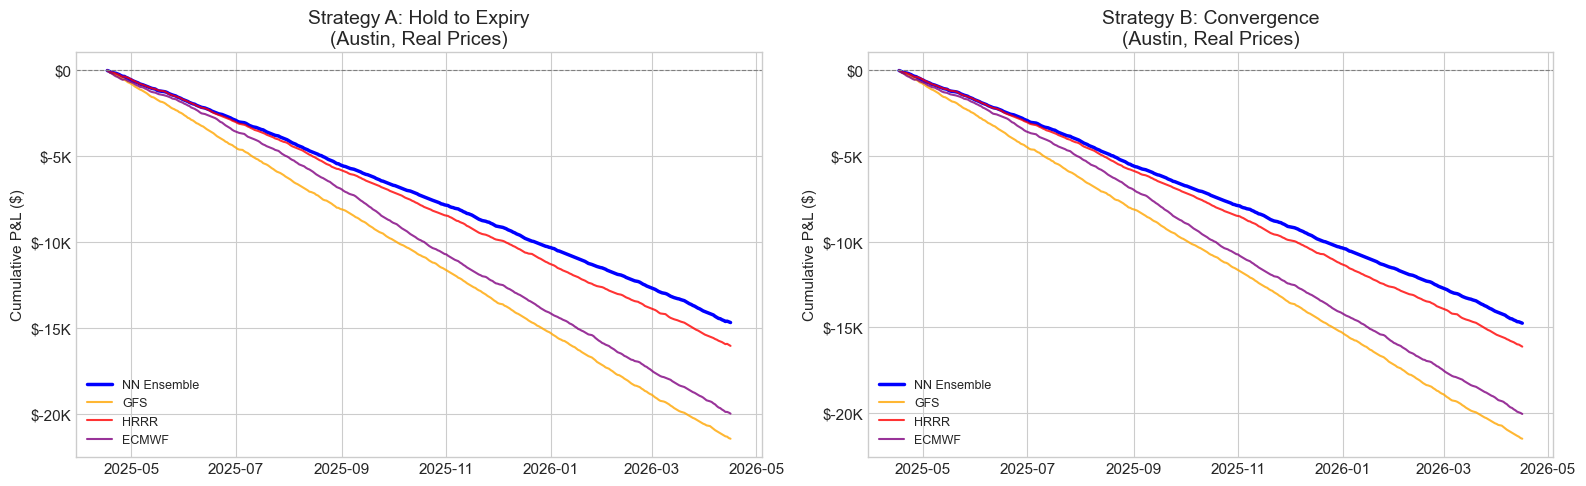

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, strat_key, strat_label in [(ax1, "a", "Strategy A: Hold to Expiry"), (ax2, "b", "Strategy B: Convergence")]:

    t = aus[f"trades_{strat_key}"]
    if not t.empty:
        daily = t.groupby("date")["pnl_dollars"].sum().sort_index()
        ax.plot(daily.index, daily.cumsum(), label="NN Ensemble", lw=2.5, color="blue")

    colors = {"GFS": "orange", "HRRR": "red", "ECMWF": "purple"}
    for name, res in aus["nwp_results"].items():
        t_nwp = res[f"trades_{strat_key}"]
        if not t_nwp.empty:
            daily_m = t_nwp.groupby("date")["pnl_dollars"].sum().sort_index()
            ax.plot(daily_m.index, daily_m.cumsum(), label=name, lw=1.5, alpha=0.8, color=colors[name])

    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_title(f"{strat_label}\n(Austin, Real Prices)")
    ax.set_ylabel("Cumulative P&L ($)")
    ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 7. Monthly P&L Breakdown (Austin)

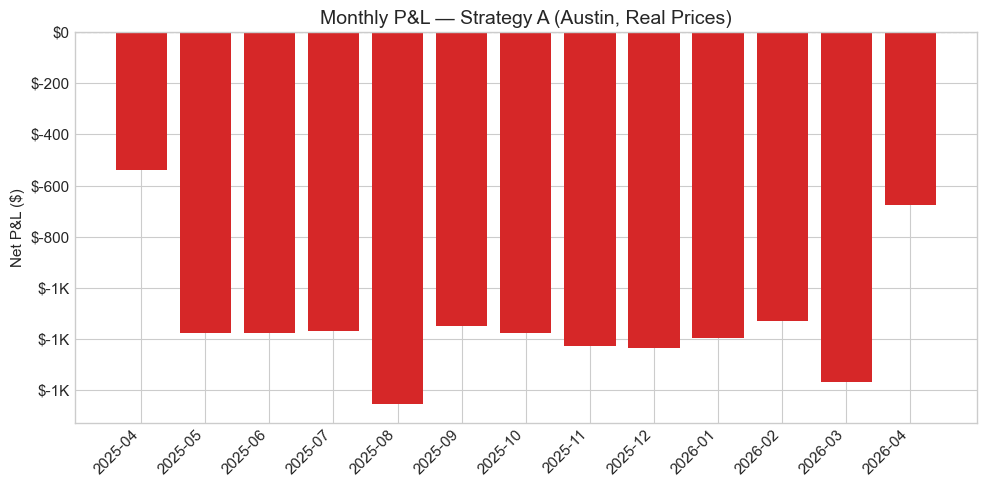

In [7]:
monthly = metrics_by_month(aus["trades_a"])

fig, ax = plt.subplots(figsize=(10, 5))
if not monthly.empty:
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in monthly["total_pnl"]]
    ax.bar(range(len(monthly)), monthly["total_pnl"], color=colors)
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha="right")
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_ylabel("Net P&L ($)")
    ax.set_title("Monthly P&L — Strategy A (Austin, Real Prices)")
    ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.show()

## 8. Edge Distribution: Why the Market is Hard to Beat

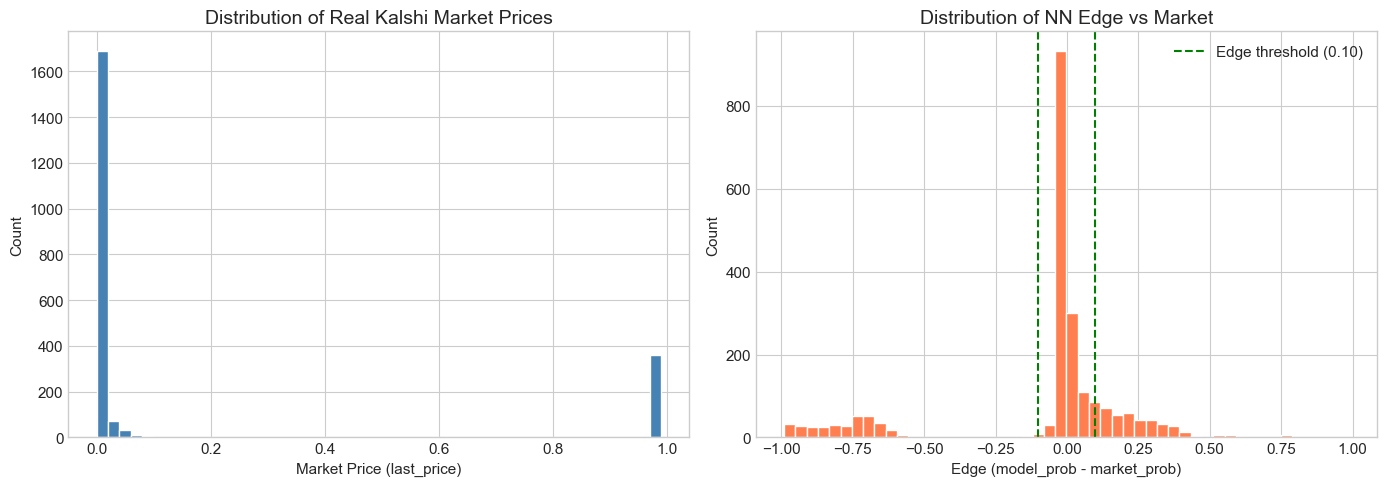

Contracts priced at extremes (<=0.02 or >=0.98): 95.7%
Contracts with |edge| > 0.10 (tradeable): 34.2%

The market is already very efficient — most contracts are priced near 0 or 1.


In [8]:
contracts = aus["contracts"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(contracts["market_prob"], bins=50, color="steelblue", edgecolor="white")
ax1.set_xlabel("Market Price (last_price)")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of Real Kalshi Market Prices")

ax2.hist(contracts["edge"], bins=50, color="coral", edgecolor="white")
ax2.axvline(0.10, color="green", ls="--", lw=1.5, label="Edge threshold (0.10)")
ax2.axvline(-0.10, color="green", ls="--", lw=1.5)
ax2.set_xlabel("Edge (model_prob - market_prob)")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of NN Edge vs Market")
ax2.legend()

fig.tight_layout()
plt.show()

pct_extreme = ((contracts["market_prob"] <= 0.02) | (contracts["market_prob"] >= 0.98)).mean()
pct_tradeable = (contracts["edge"].abs() > 0.10).mean()
print(f"Contracts priced at extremes (<=0.02 or >=0.98): {pct_extreme:.1%}")
print(f"Contracts with |edge| > 0.10 (tradeable): {pct_tradeable:.1%}")
print(f"\nThe market is already very efficient — most contracts are priced near 0 or 1.")

## 9. Sensitivity: Edge Threshold

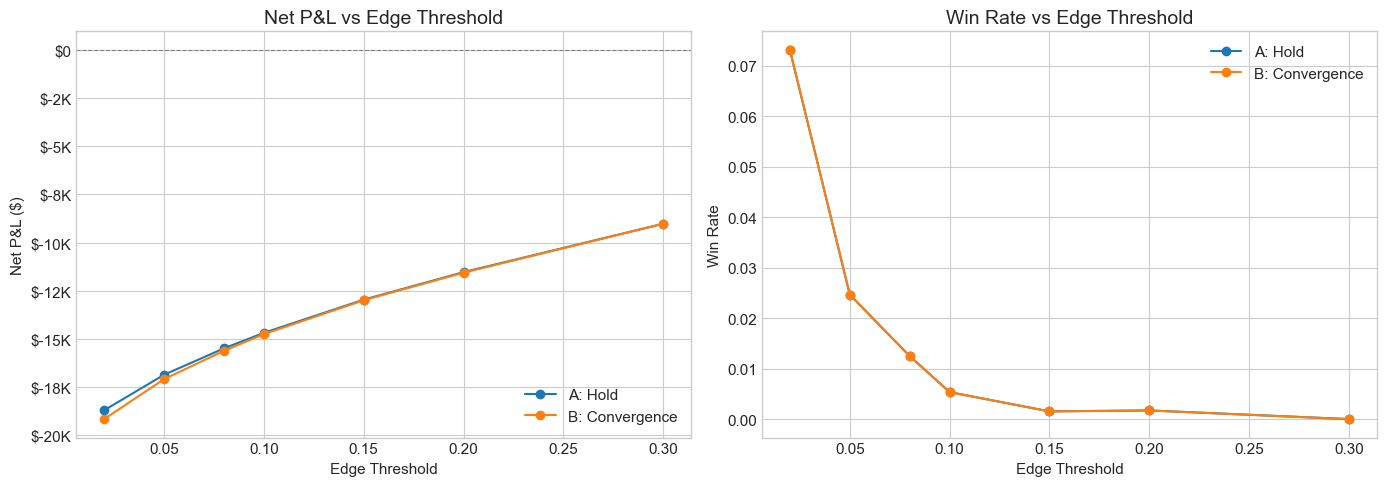

In [9]:
sens = run_sensitivity(aus["contracts"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for strat, label in [("A_hold", "A: Hold"), ("B_convergence", "B: Convergence")]:
    s = sens[sens["strategy"] == strat]
    ax1.plot(s["edge_threshold"], s["total_pnl"], marker="o", label=label)
    ax2.plot(s["edge_threshold"], s["win_rate"], marker="o", label=label)

ax1.axhline(0, color="gray", ls="--", lw=0.8)
ax1.set_xlabel("Edge Threshold"); ax1.set_ylabel("Net P&L ($)"); ax1.set_title("Net P&L vs Edge Threshold")
ax1.yaxis.set_major_formatter(FuncFormatter(dollar_fmt)); ax1.legend()

ax2.set_xlabel("Edge Threshold"); ax2.set_ylabel("Win Rate"); ax2.set_title("Win Rate vs Edge Threshold")
ax2.legend()

fig.tight_layout()
plt.show()

## 10. Conclusion

**Key finding:** With real Kalshi market prices, no model — including the NN — generates positive P&L after fees. The Kalshi temperature market is efficient: most contracts settle at extreme prices (0.01 or 0.99), leaving little room for a forecasting edge to exploit.

**However, the NN consistently loses less than all individual NWP models**, confirming its superior forecasting accuracy even when that accuracy isn't sufficient to overcome market efficiency + transaction costs. This is the expected result for a well-functioning prediction market.

### Assumptions
- **Price-taking** — 250 contracts/trade doesn't move the market
- **Execution at last_price** — no bid-ask spread friction beyond what's in last_price
- **Kalshi taker fees** — min(7% of potential profit, 7 cents/contract) on every trade
- **Real market prices** — all prices from Kalshi API (no simulated proxies)